<a href="https://colab.research.google.com/github/KaarthiKeyanV/Google-capstone-project/blob/main/Internship_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/cloud_retail_sales_2025.csv")
df.head()


,Invoice_ID,Date,Customer_ID,Customer_Age,Product_Category,Product_Name,Unit_Price,Quantity,Total_Amount,Payment_Mode,Store_Location,Rating
0,INV1000,2025-05-21,C799,52,Electronics,Keyboard,2818,5,14090,UPI,East,2
1,INV1001,2025-08-19,C4222,56,Home Decor,Table Lamp,1950,5,9750,COD,East,1
2,INV1002,2025-06-25,C1921,18,Fashion,Men T-Shirt,2508,4,10032,Credit Card,North,2
3,INV1003,2025-07-17,C3887,57,Beauty,Shampoo,898,5,4490,Credit Card,North,3
4,INV1004,2025-09-27,C3792,46,Beauty,Shampoo,1591,2,3182,Debit,West,1


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes


,0
Invoice_ID,object
Date,datetime64[ns]
Customer_ID,object
Customer_Age,int64
Product_Category,object
Product_Name,object
Unit_Price,int64
Quantity,int64
Total_Amount,int64
Payment_Mode,object


In [ ]:
df.shape
df.info()
df.describe()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Invoice_ID        65000 non-null  object        
 1   Date              65000 non-null  datetime64[ns]
 2   Customer_ID       65000 non-null  object        
 3   Customer_Age      65000 non-null  int64         
 4   Product_Category  65000 non-null  object        
 5   Product_Name      65000 non-null  object        
 6   Unit_Price        65000 non-null  int64         
 7   Quantity          65000 non-null  int64         
 8   Total_Amount      65000 non-null  int64         
 9   Payment_Mode      65000 non-null  object        
 10  Store_Location    65000 non-null  object        
 11  Rating            65000 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(6)
memory usage: 6.0+ MB


Index(['Invoice_ID', 'Date', 'Customer_ID', 'Customer_Age', 'Product_Category',
       'Product_Name', 'Unit_Price', 'Quantity', 'Total_Amount',
       'Payment_Mode', 'Store_Location', 'Rating'],
      dtype='object')

In [ ]:
df.isna().sum()
df.duplicated().sum()
df = df.drop_duplicates()


In [ ]:
df['Month'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year


In [ ]:
df.to_csv("/content/cleaned_retail_sales_2025.csv", index=False)


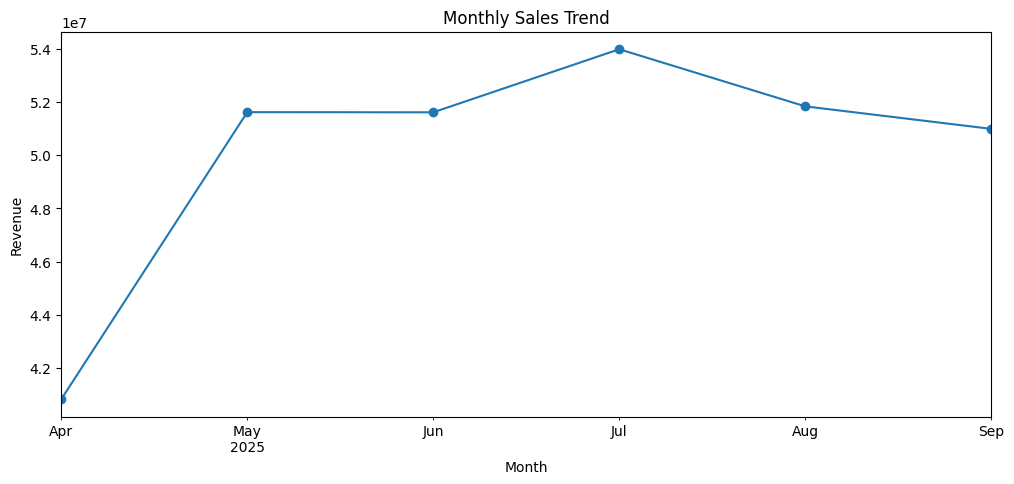

In [ ]:
#EDA(Charts)

monthly = df.groupby('Month')['Total_Amount'].sum()

plt.figure(figsize=(12,5))
monthly.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

# Monthly Sales Trend


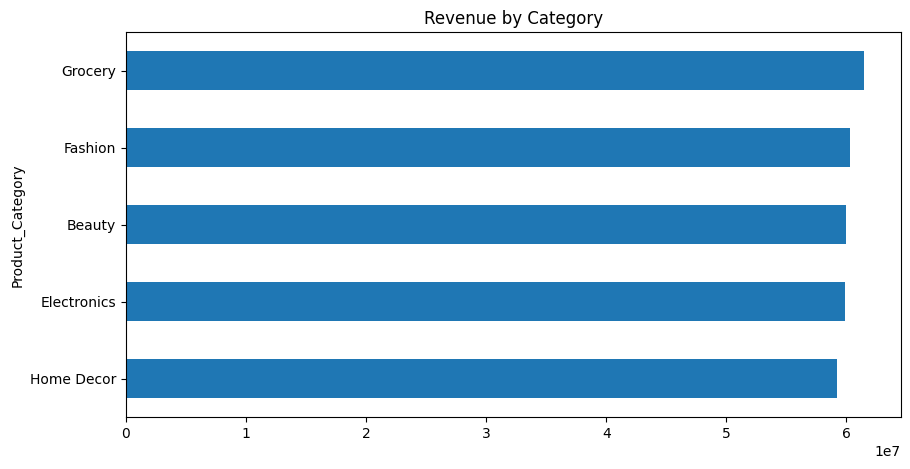

In [ ]:
#Category-Wise Revenue

cat_rev = df.groupby('Product_Category')['Total_Amount'].sum()

plt.figure(figsize=(10,5))
cat_rev.sort_values().plot(kind='barh')
plt.title("Revenue by Category")
plt.show()



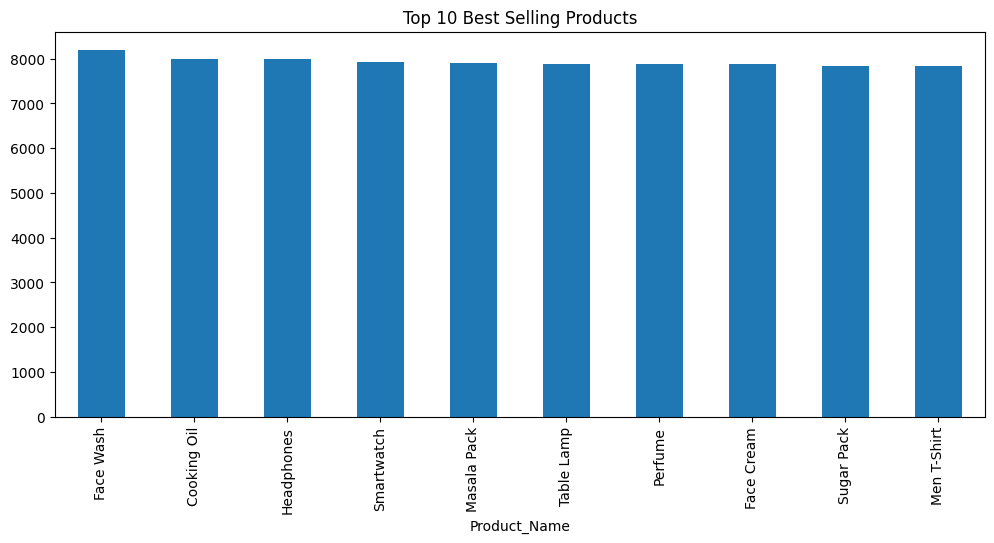

In [ ]:
#Top 10 products

top10 = df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top10.plot(kind='bar')
plt.title("Top 10 Best Selling Products")
plt.show()



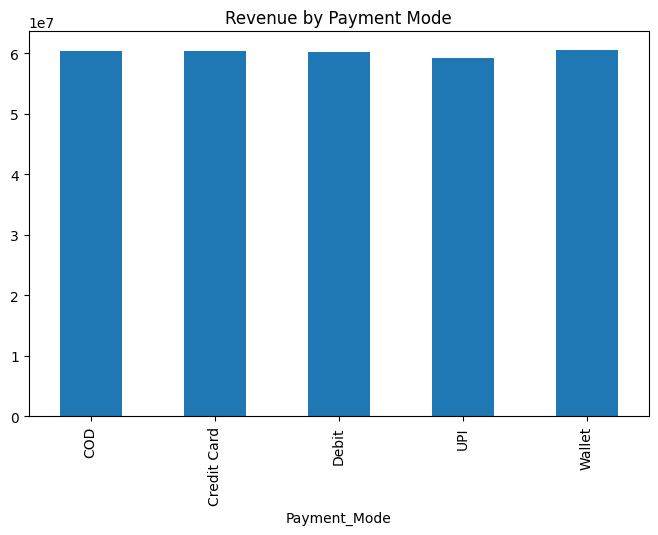

In [ ]:
#Patment Mode Analysis

pmode = df.groupby('Payment_Mode')['Total_Amount'].sum()

plt.figure(figsize=(8,5))
pmode.plot(kind='bar')
plt.title("Revenue by Payment Mode")
plt.show()



In [ ]:

#Create Snapshot Date


snapshot_date = df['Date'].max() + pd.Timedelta(days=1)
snapshot_date


Timestamp('2025-10-01 00:00:00')

In [ ]:
#Building RFM Table

rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (snapshot_date - x.max()).days,   # Recency
    'Invoice_ID': 'nunique',                            # Frequency
    'Total_Amount': 'sum'                               # Monetary
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,Customer_ID,Recency,Frequency,Monetary
0,C1,17,14,64214
1,C10,50,11,49088
2,C100,22,16,69780
3,C1000,6,16,83305
4,C1001,36,15,75496


In [ ]:
#Standardize Scale RFM values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
rfm_scaled[:5]



array([[ 0.20994102,  0.27830224,  0.19199949],
       [ 2.64442464, -0.55660447, -0.52691192],
       [ 0.57880217,  0.83490671,  0.4565414 ],
       [-0.60155353,  0.83490671,  1.09936018],
       [ 1.6116134 ,  0.55660447,  0.72821254]])

In [ ]:
#Applying K-Means

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()




,Customer_ID,Recency,Frequency,Monetary,Cluster
0,C1,17,14,64214,3
1,C10,50,11,49088,1
2,C100,22,16,69780,3
3,C1000,6,16,83305,2
4,C1001,36,15,75496,1


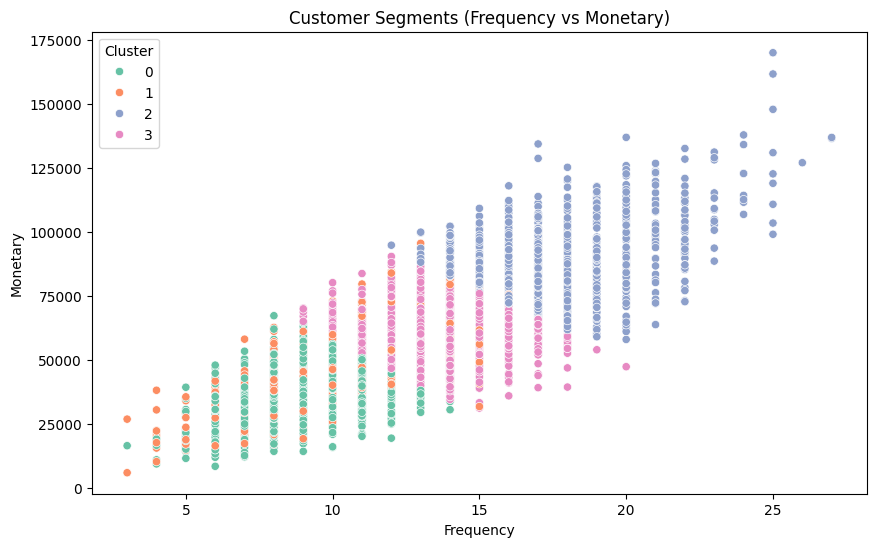

In [ ]:
#Visualize Customer Segments

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title("Customer Segments (Frequency vs Monetary)")
plt.show()



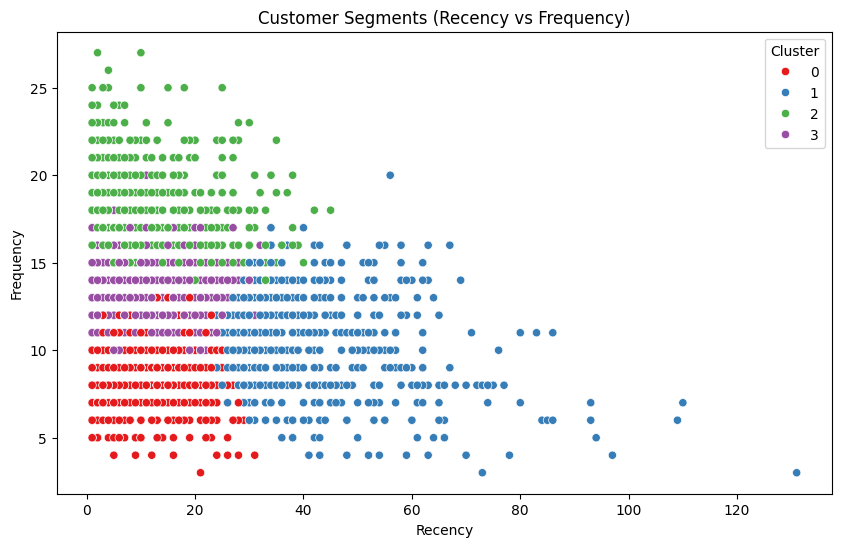

In [ ]:
#Recency VS Frequency

plt.figure(figsize=(10,6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1')
plt.title("Customer Segments (Recency vs Frequency)")
plt.show()





In [ ]:
rfm.to_csv("/content/rfm_table.csv", index=False)


In [ ]:
from google.colab import files
files.download('/content/rfm_table.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Product and Sales Performance Analysis


#Caategory-Level-Performance

category = df.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum'
}).sort_values('Total_Amount', ascending=False)

category



,Quantity,Total_Amount
Product_Category,,
Grocery,39078,61455577
Fashion,38742,60332076
Beauty,39315,60007568
Electronics,39000,59898641
Home Decor,38458,59177653


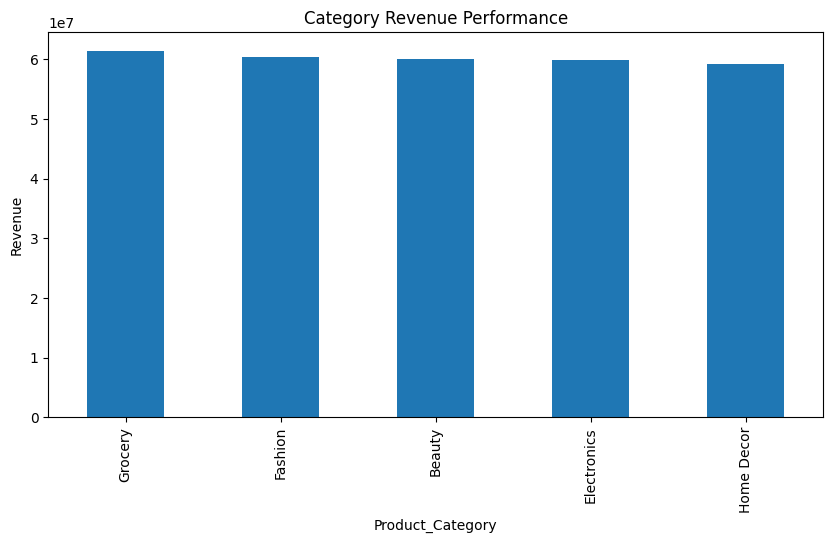

In [ ]:
#Visulation

category['Total_Amount'].plot(kind='bar', figsize=(10,5))
plt.title("Category Revenue Performance")
plt.ylabel("Revenue")
plt.show()


In [ ]:
#Poduct Level Performance

product = df.groupby('Product_Name').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum'
}).sort_values('Quantity', ascending=False)

product.head(10)   # Top 10 sellers


,Quantity,Total_Amount
Product_Name,,
Face Wash,8192,12522331
Cooking Oil,7991,12686421
Headphones,7987,12281578
Smartwatch,7927,12272276
Masala Pack,7897,12354942
Table Lamp,7888,11967240
Perfume,7887,11872153
Face Cream,7875,11921156
Sugar Pack,7841,12269067


In [ ]:
#Worst Performing

product.tail(10)


,Quantity,Total_Amount
Product_Name,,
Bluetooth Speaker,7716,11718848
Cushion Set,7713,11927302
Flower Vase,7711,11838330
Organic Rice,7704,12267985
Body Lotion,7700,11795425
Shampoo,7661,11896503
Tea Powder,7645,11877162
Keyboard,7636,11713975
Ladies Kurti,7589,11869948


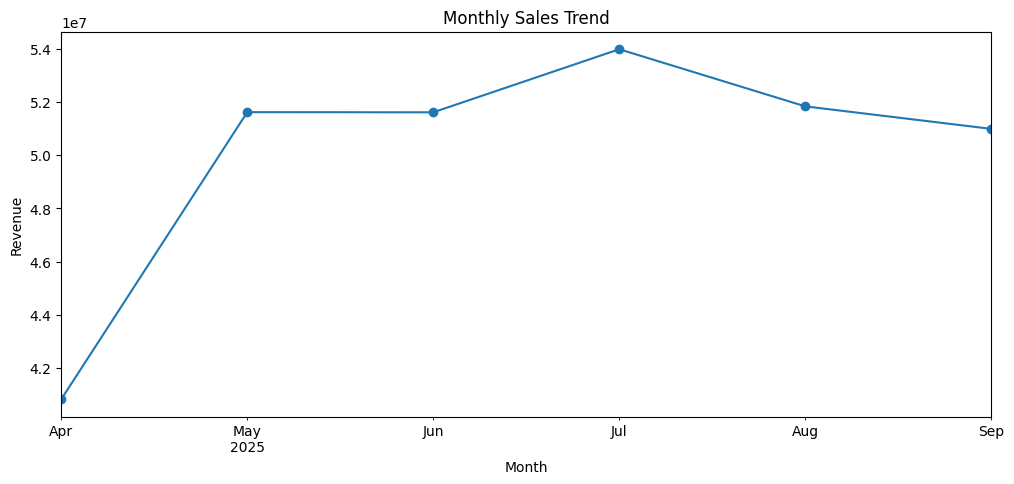

In [ ]:
#Trend Analysis(Monthly)

monthly = df.groupby('Month')['Total_Amount'].sum()

monthly.plot(figsize=(12,5), marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()




In [ ]:
#creating Monthly Revenue

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total_Amount'].sum()
monthly_sales = monthly_sales.to_timestamp()
monthly_sales



,Total_Amount
Date,
2025-04-01,40825338
2025-05-01,51619266
2025-06-01,51613939
2025-07-01,53984794
2025-08-01,51837082
2025-09-01,50991096


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Date'>

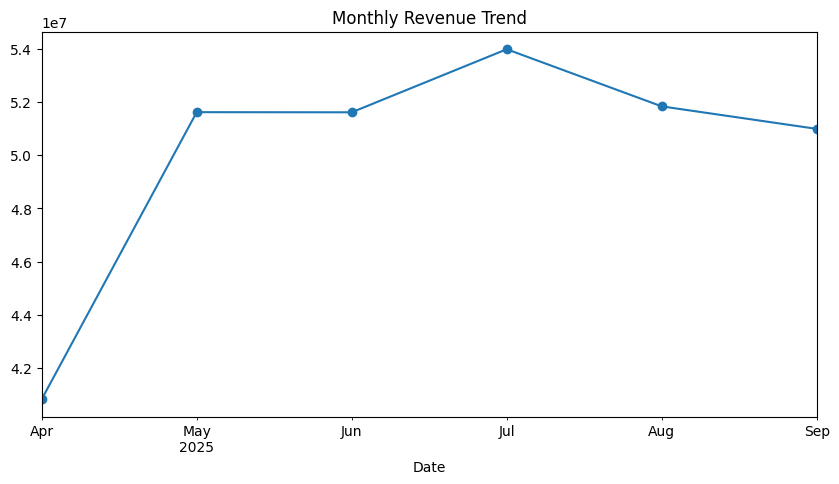

In [ ]:
#Plot the Monthly Sales

monthly_sales.plot(figsize=(10,5), marker='o', title="Monthly Revenue Trend")


In [ ]:
#ARIMA FORECAST

!pip install pmdarima

#installing Libary


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.2 MB/s eta 0:00:00


In [ ]:
#Predict Next 3 Months

from pmdarima import auto_arima

model = auto_arima(monthly_sales, seasonal=False, trace=True)
model.fit(monthly_sales)


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=272.975, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=231.836, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=230.918, Time=0.02 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=213.593, Time=0.05 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=215.566, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=39762021991.961, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=215.593, Time=0.11 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 0.507 seconds


ARIMA(order=(1, 0, 2), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [ ]:
rfm.to_csv("/content/rfm_cluster_output.csv", index=False)


In [ ]:
#Creating forecast data Frame

forecast = model.predict(n_periods=3)

future_dates = pd.date_range(start=monthly_sales.index[-1] + pd.offsets.MonthBegin(),
                             periods=3, freq='MS')

forecast_df = pd.DataFrame({'Month': future_dates, 'Predicted_Sales': forecast})
forecast_df

,Month,Predicted_Sales
2025-10-01,2025-10-01,5.079657e+07
2025-11-01,2025-11-01,5.053161e+07
2025-12-01,2025-12-01,4.961303e+07


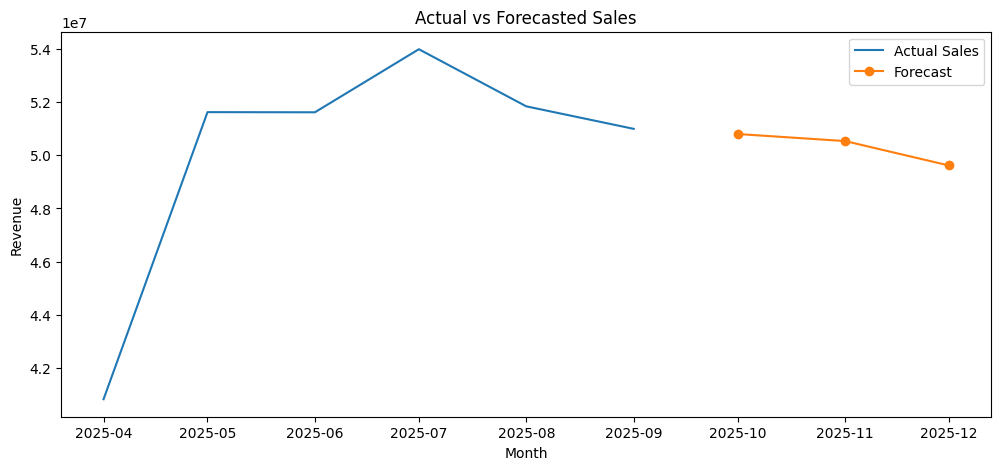

In [ ]:
#Plot Actual vs Forecast

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual Sales')
plt.plot(future_dates, forecast, label='Forecast', marker='o')
plt.title("Actual vs Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.show()




In [ ]:
forecast_df.to_csv("/content/month4_sales_forecast.csv", index=False)



In [ ]:
# 📌 Month 1 – Data Cleaning & EDA
# 📌 Month 2 – Customer Segmentation (RFM + K-Means)
# 📌 Month 3 – Product Analysis & Sales Insights
# 📌 Month 4 – Sales Forecasting
# 📌 Month 5 – Dashboard (Python plots)
# 📌 Month 6 – Final Insights & Business Recommendations


In [ ]:
from google.colab import files
files.download('/content/cleaned_retail_sales_2025.csv')

#Cleaned Retail sales

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('/content/rfm_cluster_output.csv')

#RFM file

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('/content/month4_sales_forecast.csv')

#Forecast fIle


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>